# Homework 1 - Convolutions

In [30]:
begin
    import Pkg
    Pkg.activate(mktempdir())
end

  Activating new project at `C:\Users\msule\AppData\Local\Temp\jl_w8agQv`


In [31]:
begin
    Pkg.add(["Images", "ImageMagick"])
    using Images
end

   Resolving package versions...
    Updating `C:\Users\msule\AppData\Local\Temp\jl_w8agQv\Project.toml`
  [6218d12a] + ImageMagick v1.4.0
  [916415d5] + Images v0.26.1
    Updating `C:\Users\msule\AppData\Local\Temp\jl_w8agQv\Manifest.toml`
  [621f4979] + AbstractFFTs v1.5.0
  [79e6a3ab] + Adapt v4.1.1
  [ec485272] + ArnoldiMethod v0.4.0
  [4fba245c] + ArrayInterface v7.17.1
  [13072b0f] + AxisAlgorithms v1.1.0
  [39de3d68] + AxisArrays v0.4.7
  [62783981] + BitTwiddlingConvenienceFunctions v0.1.6
  [fa961155] + CEnum v0.5.0
  [2a0fbf3d] + CPUSummary v0.2.6
  [aafaddc9] + CatIndices v0.2.2
  [d360d2e6] + ChainRulesCore v1.25.0
  [fb6a15b2] + CloseOpenIntervals v0.1.13
  [aaaa29a8] + Clustering v0.15.7
  [35d6a980] + ColorSchemes v3.27.1
  [3da002f7] + ColorTypes v0.12.0
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.0
  [f70d9fcc] + CommonWorldInvalidations v1.0.0
  [34da2185] + Compat v4.16.0
  [ed09eef8] + ComputationalResources v0.3.2
  [187b0558] + Constructio

In [32]:
bigbreak = html"<br><br><br><br><br>";

## Exercise 1 - Manipulating Vectors (1D images)

A Vector is a 1D array. We can think of that as a 1D image.

In [33]:
example_vector = [0.5, 0.4, 0.3, 0.2, 0.1, 0.0, 0.7, 0.0, 0.7, 0.9]

10-element Vector{Float64}:
 0.5
 0.4
 0.3
 0.2
 0.1
 0.0
 0.7
 0.0
 0.7
 0.9

In [34]:
begin
    colored_line(x::Vector{<:Real}) = Gray.(Float64.((hcat(x)')))
    colored_line(x::Any) = nothing
end

colored_line (generic function with 2 methods)

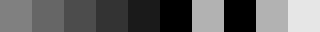

In [35]:
colored_line(example_vector)

### Exercise 1.1

Make a random vector random_vect of length 10 using the rand function.

In [36]:
random_vect = rand(Int64, 10)

10-element Vector{Int64}:
  1724587711108564922
 -4527475422429213309
 -7793038696810222660
  8835006373041235281
 -4931014357189333090
  1602043528292143111
   150590368724191192
  9215321469454756246
  3119557791025633084
 -1957562384586091313

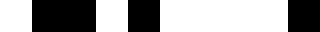

In [37]:
colored_line(random_vect)

Make a function mean using a for loop, which computes the mean/average of a vector of numbers.

In [38]:
function mean(x)
	x_sum = 0
	for n in x
		x_sum += n
	end
	return x_sum / length(x)
end

mean (generic function with 1 method)

In [39]:
mean([1, 2, 3])

2.0

Define m to be the mean of random_vect.

In [40]:
m = mean(random_vect)

5.4380163806316634e17

Write a function demean, which takes a vector x and subtracts the mean from each value in x.

In [41]:
function demean(x)
	mean_x = mean(x)
	for (i, n) in enumerate(x)
		x[i] = n - mean_x
	end
	return x
end

demean (generic function with 1 method)

In [42]:
mean(demean(random_vect))

-25.6

### Exercise 1.2

Generate a vector of 100 zeros. Change the center 20 elements to 1.

In [43]:
function create_bar()
    vect = zeros(Int, 100)
    vect[40:60] .= 1
	return vect
end

create_bar (generic function with 1 method)

In [44]:
colored_line(create_bar())

### Exercise 1.3

Write a function that turns a Vector of Vectors into a Matrix.

In [45]:
function vecvec_to_matrix(vecvec)
	return hcat(vecvec...)
end

vecvec_to_matrix (generic function with 1 method)

In [46]:
vecvec_to_matrix([[1,2], [3,4]])

2×2 Matrix{Int64}:
 1  3
 2  4

Write a function that turns a Matrix into a Vector of Vectors.

In [47]:
function matrix_to_vecvec(matrix)
    return [col for col in eachcol(matrix)]
end

matrix_to_vecvec (generic function with 1 method)

In [48]:
matrix_to_vecvec([6 7; 8 9])

2-element Vector{SubArray{Int64, 1, Matrix{Int64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}:
 [6, 8]
 [7, 9]

## Exercise 2 - Manipulating Images

In this exercise we will get familiar with matrices (2D arrays) in Julia, by manipulating images. Recall that in Julia images are matrices of RGB color objects.

Let's load a picture of Philip again.

In [49]:
philip_file = download("https://i.imgur.com/VGPeJ6s.jpg")

"C:\\Users\\msule\\AppData\\Local\\Temp\\jl_ivyPyZsXWJ"

In [50]:
decimate(image, ratio=5) = image[1:ratio:end, 1:ratio:end]

decimate (generic function with 2 methods)

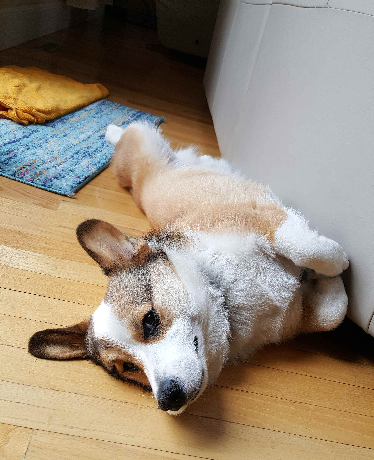

In [51]:
philip = let
	original = Images.load(philip_file)
	decimate(original, 8)
end

### Exercise 2.1
👉 Write a function mean_colors that accepts an object called image. It should calculate the mean (average) amounts of red, green and blue in the image and return a tuple (r, g, b) of those means.

In [52]:
function mean_colors(image)
	(h, w) = size(image)
    avg_r, avg_g, avg_b = (0, 0, 0)
    num = h * w
    for r in 1:h
        for c in 1:w
            avg_r += image[r, c].r / num
            avg_g += image[r, c].g / num
            avg_b += image[r, c].b / num
        end
    end

	return (avg_r, avg_g, avg_b)
end

mean_colors (generic function with 1 method)

In [53]:
p3 = copy(philip)
mean_colors(p3)

(0.6003652f0, 0.54742175f0, 0.4794529f0)

### Exercise 2.2
👉 Look up the documentation on the floor function. Use it to write a function quantize(x::Number) that takes in a value 
 (which you can assume is between 0 and 1) and "quantizes" it into bins of width 0.1. For example, check that 0.267 gets mapped to 0.2.

In [58]:
begin
	function quantize(x::Number)
		return floor(x, digits=2)
	end
	
	function quantize(color::AbstractRGB)
		return RGB(floor(color.r, digits=2), floor(color.g, digits=2), floor(color.b, digits=2))
	end
	
	function quantize(image::AbstractMatrix)
		return quantize.(image)
	end
end

quantize (generic function with 3 methods)

In [59]:
quantize(0.267), quantize(0.91)

(0.26, 0.91)

### Exercise 2.3
👉 Write the second method of the function quantize, i.e. a new version of the function with the same name. This method will accept a color object called color, of the type AbstractRGB.

Write the function in the same cell as quantize(x::Number) from the last exercise. 👆

Here, ::AbstractRGB is a type annotation. This ensures that this version of the function will be chosen when passing in an object whose type is a subtype of the AbstractRGB abstract type. For example, both the RGB and RGBX types satisfy this.

The method you write should return a new RGB object, in which each component (
, 
 and 
) are quantized.



### Exercise 2.4
👉 Write a method quantize(image::AbstractMatrix) that quantizes an image by quantizing each pixel in the image. (You may assume that the matrix is a matrix of color objects.)

Write the function in the same cell as quantize(x::Number) from the last exercise. 👆



Let's apply your method!

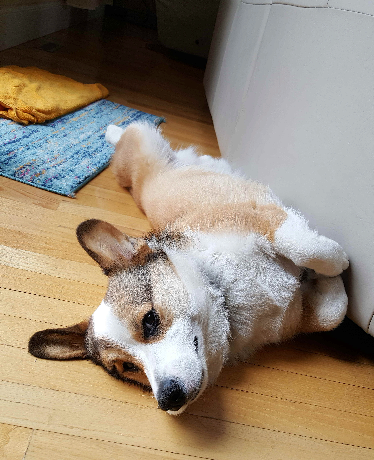

In [60]:
quantize(philip)

### Exercise 2.5
👉 Write a function invert that inverts a color, i.e. sends (r, g, b) to (1 - r, 1 - g, 1 - b).

In [69]:
function invert(color::AbstractRGB)
    return RGB(1-color.r, 1-color.g, 1-color.b)
end

invert (generic function with 1 method)

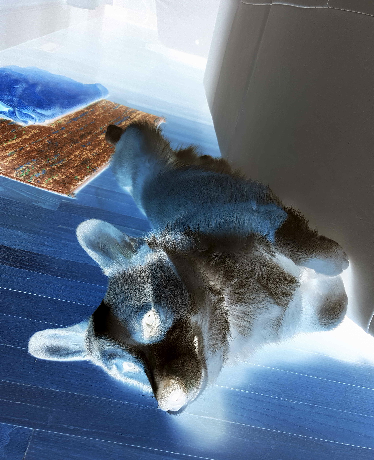

In [72]:
philipa = copy(philip)
invert.(philipa)


### Exercise 2.6
👉 Write a function noisify(x::Number, s) to add randomness of intensity s 
 to a value x
, i.e. to add a random value between -s
 and +s
 to x
. If the result falls outside the range 
 you should "clamp" it to that range. (Note that Julia has a clamp function, but you should write your own function myclamp(x).)

In [78]:
begin
    function noisify(x::Number, s)
        random = rand()
		return abs(x + random) > abs(x + s) ? x + s : x + random
    end

    function noisify(color::AbstractRGB, s)
        return RGB(noisify(color.r, s), noisify(color.b, s), noisify(color.g, s))
    end

    function noisify(image::AbstractMatrix, s)
        return noisify.(image, s)
    end
end

noisify (generic function with 3 methods)

 👉Write the second method noisify(c::AbstractRGB, s) to add random noise of intensity 
 to each of the (r, g, b)
 values in a colour.

Write the function in the same cell as noisify(x::Number) from the last exercise. 👆

In [79]:
Pkg.add("Interact")

   Resolving package versions...
   Installed AssetRegistry ───────── v0.1.0
   Installed Pidfile ─────────────── v1.3.0
   Installed WebSockets ──────────── v1.6.0
   Installed Knockout ────────────── v0.2.6
   Installed ColorVectorSpace ────── v0.10.0
   Installed Interact ────────────── v0.10.5
   Installed HTTP ────────────────── v1.10.13
   Installed Widgets ─────────────── v0.6.7
   Installed WebIO ───────────────── v0.8.21
   Installed JSExpr ──────────────── v0.5.4
   Installed FunctionalCollections ─ v0.5.0
   Installed CSSUtil ─────────────── v0.1.1
   Installed Observables ─────────── v0.5.5
   Installed InteractBase ────────── v0.10.10
    Updating `C:\Users\msule\AppData\Local\Temp\jl_w8agQv\Project.toml`
  [c601a237] + Interact v0.10.5
    Updating `C:\Users\msule\AppData\Local\Temp\jl_w8agQv\Manifest.toml`
  [bf4720bc] + AssetRegistry v0.1.0
  [d1d4a3ce] + BitFlags v0.1.9
  [70588ee8] + CSSUtil v0.1.1
  [944b1d66] + CodecZlib v0.7.6
⌅ [3da002f7] ↓ ColorTypes v0.12.0 ⇒ v0

In [ ]:
using Interact

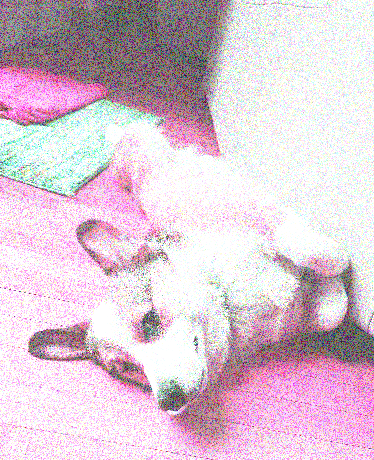

In [80]:
red = RGB(1, 0, 0)
noisify.(philipa, 0.5)